<a href="https://colab.research.google.com/github/fernandodeeke/sistemas_dinamicos/blob/main/dois_tanques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

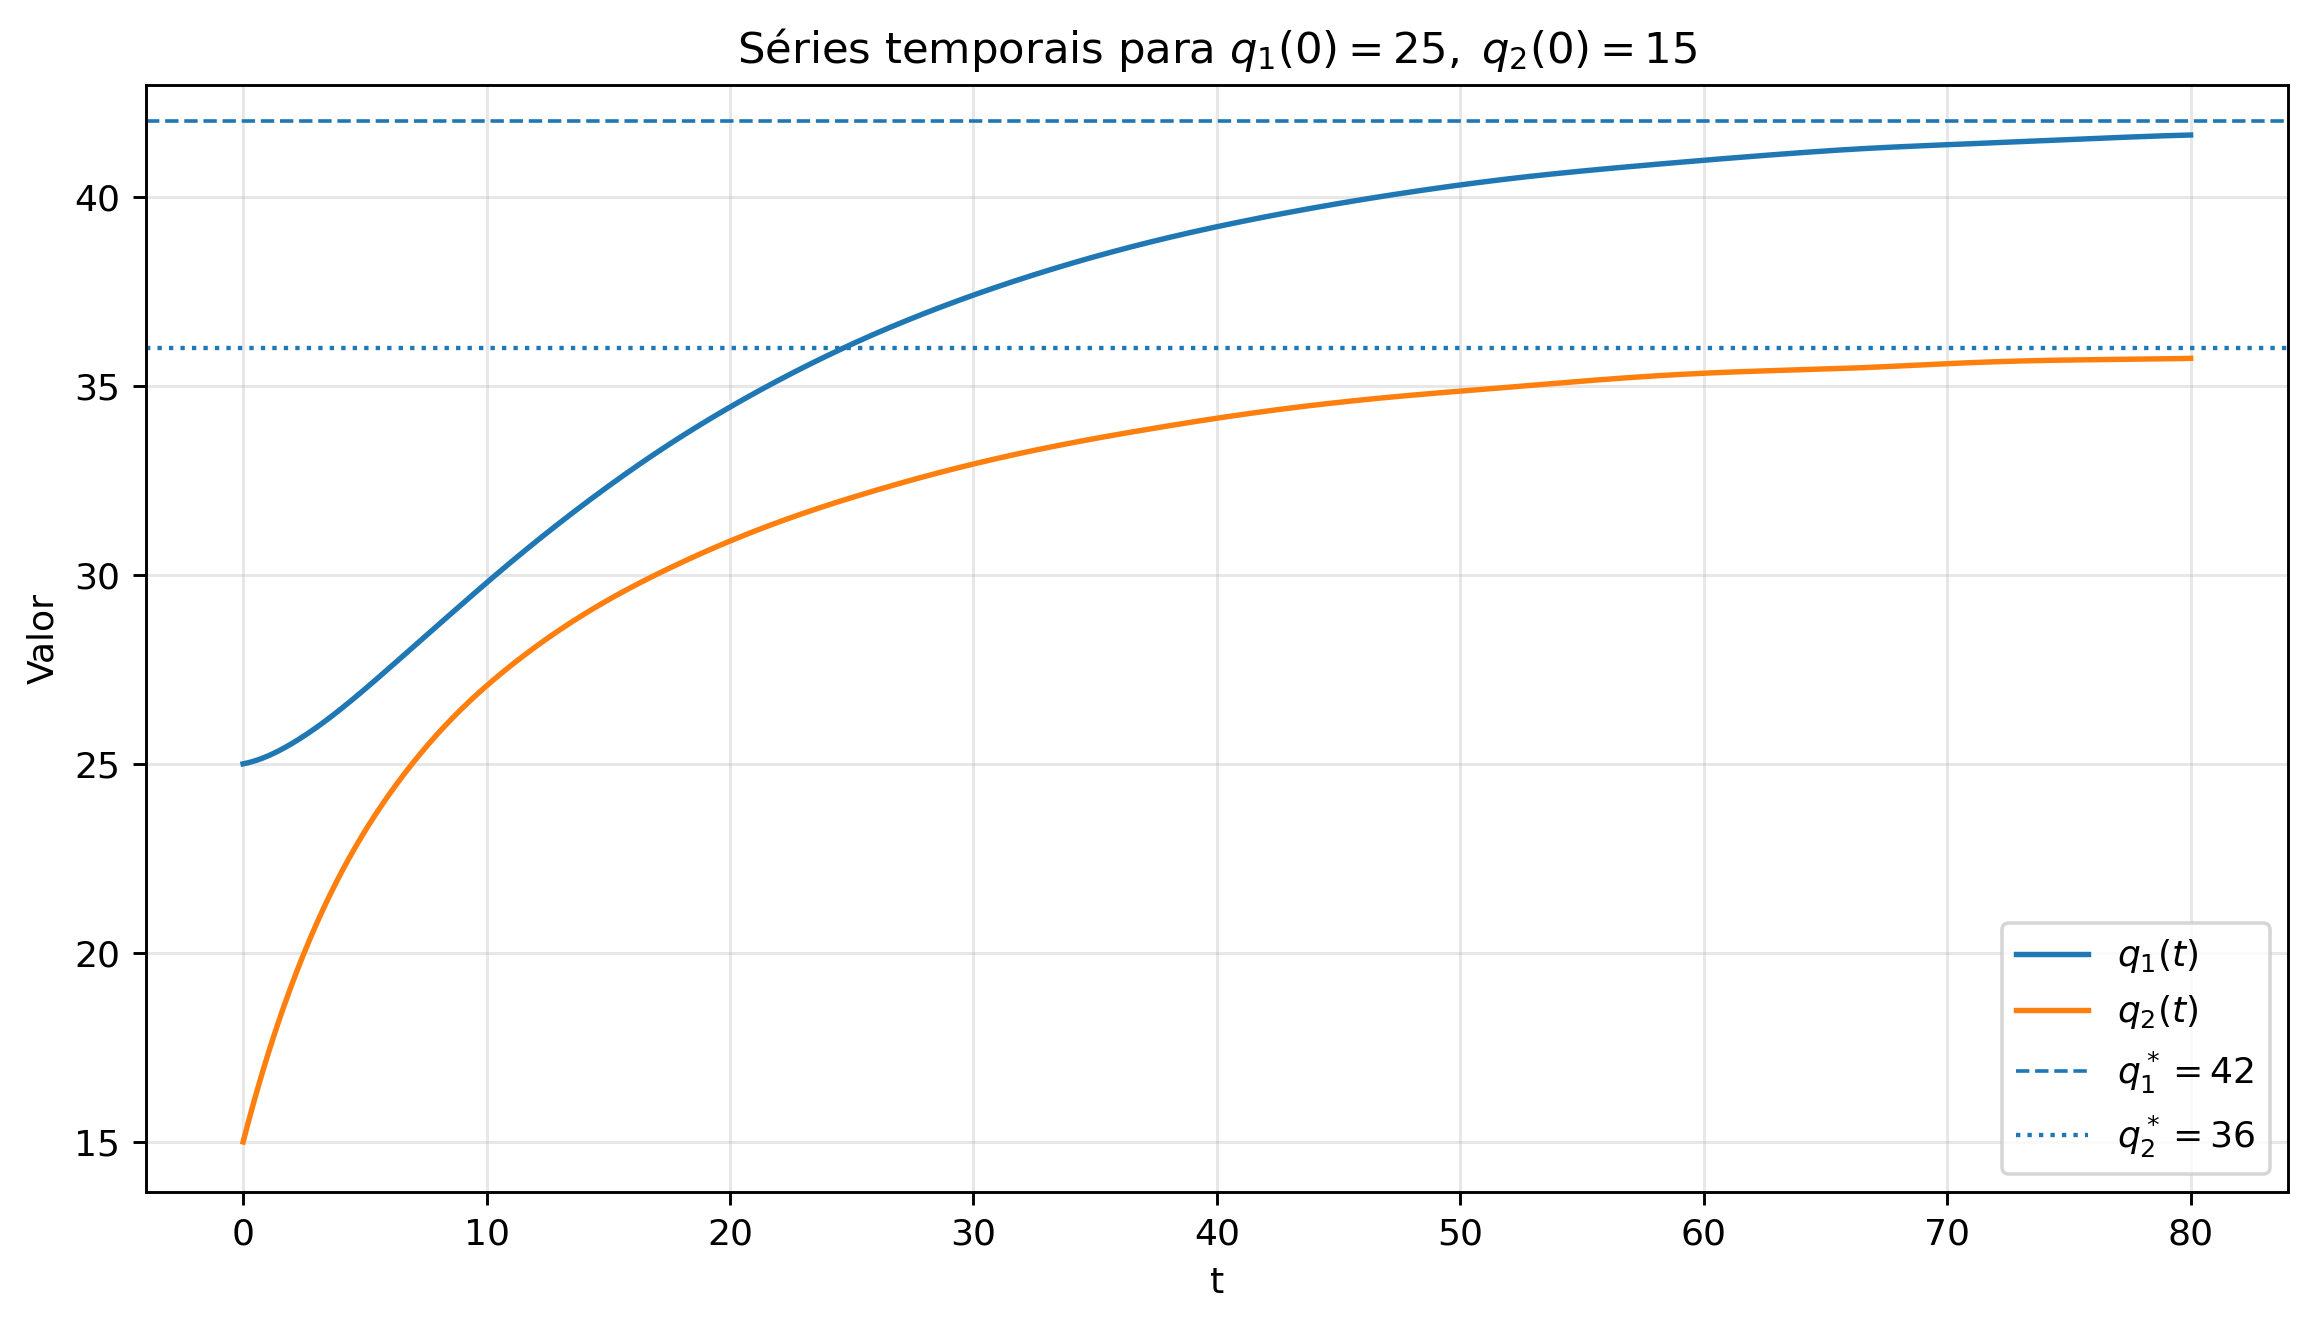

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

def sistema(t, q):
    q1, q2 = q
    dq1 = -q1/10 + 1.5*q2/20 + 1.5
    dq2 =  q1/10 - q2/5 + 3
    return [dq1, dq2]

# Condições iniciais
q0 = [25.0, 15.0]

# Intervalo de tempo
t0, tf = 0.0, 80.0
t_eval = np.linspace(t0, tf, 1200)

# Integração numérica
sol = solve_ivp(sistema, (t0, tf), q0, t_eval=t_eval, method="RK45")
t = sol.t
q1 = sol.y[0]
q2 = sol.y[1]

# Ponto de equilíbrio
q1_eq = 42.0
q2_eq = 36.0

# Gráfico das séries temporais
plt.figure(figsize=(9, 5.2), dpi=260)
plt.plot(t, q1, label=r"$q_1(t)$")
plt.plot(t, q2, label=r"$q_2(t)$")
plt.axhline(q1_eq, linestyle="--", linewidth=1, label=r"$q_1^*=42$")
plt.axhline(q2_eq, linestyle=":", linewidth=1.2, label=r"$q_2^*=36$")
plt.xlabel("t")
plt.ylabel("Valor")
plt.title(r"Séries temporais para $q_1(0)=25,\; q_2(0)=15$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



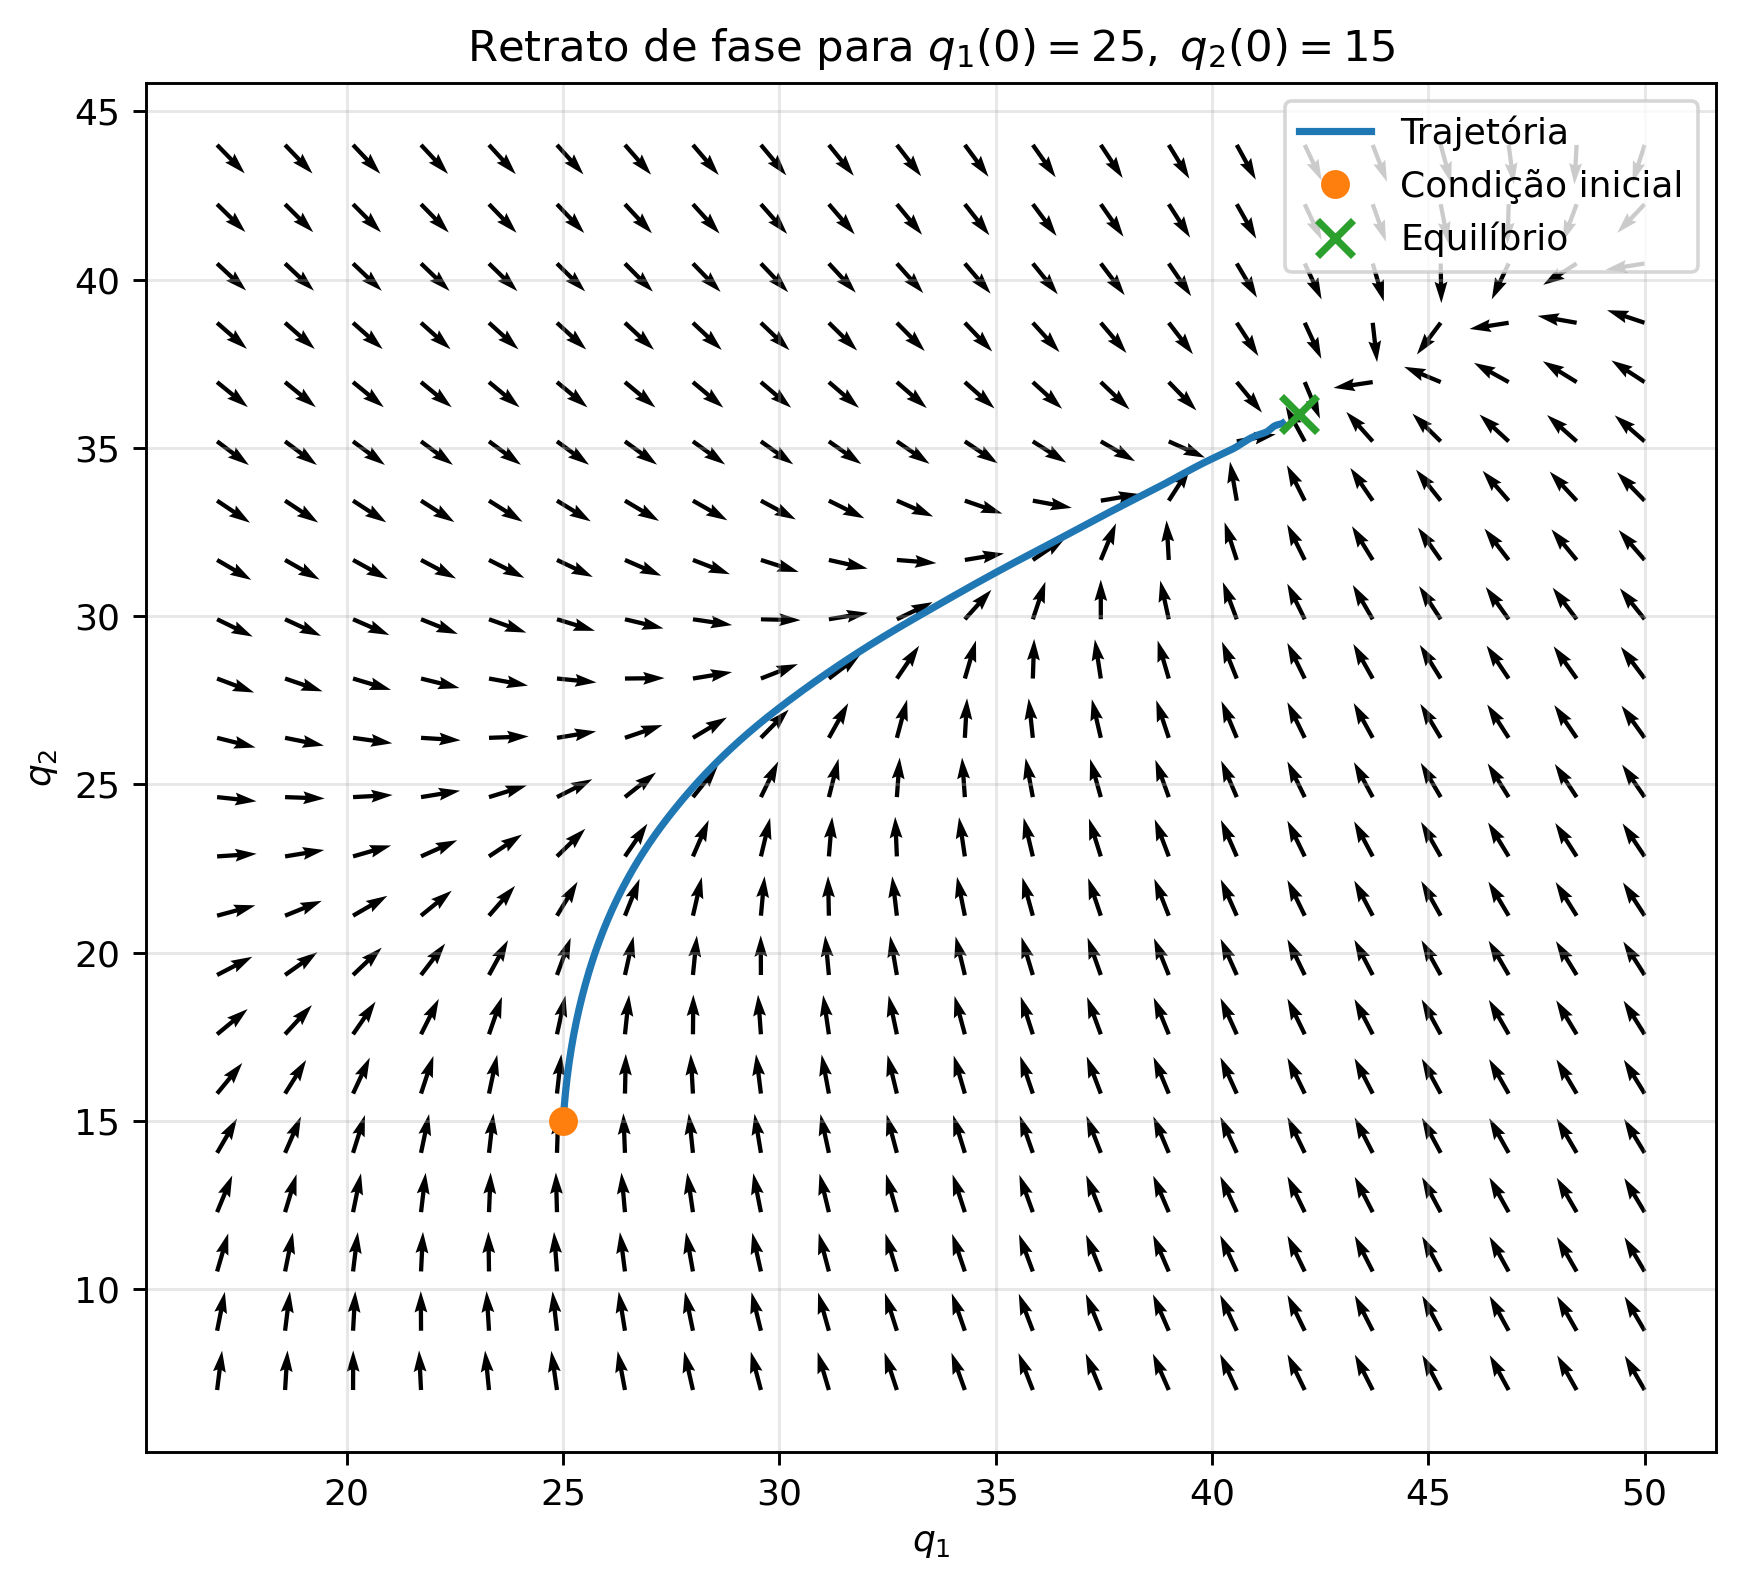

In [5]:
# Retrato de fase
q1_min = min(q1.min(), q1_eq, q0[0]) - 8
q1_max = max(q1.max(), q1_eq, q0[0]) + 8
q2_min = min(q2.min(), q2_eq, q0[1]) - 8
q2_max = max(q2.max(), q2_eq, q0[1]) + 8

Q1, Q2 = np.meshgrid(
    np.linspace(q1_min, q1_max, 22),
    np.linspace(q2_min, q2_max, 22)
)

dQ1 = -Q1/10 + 1.5*Q2/20 + 1.5
dQ2 =  Q1/10 - Q2/5 + 3
norm = np.sqrt(dQ1**2 + dQ2**2)
norm[norm == 0] = 1.0

plt.figure(figsize=(6.8, 6.2), dpi=260)
plt.quiver(Q1, Q2, dQ1/norm, dQ2/norm, angles="xy")
plt.plot(q1, q2, linewidth=2, label="Trajetória")
plt.plot(q0[0], q0[1], marker="o", linestyle="None", markersize=7, label="Condição inicial")
plt.plot(q1_eq, q2_eq, marker="x", linestyle="None", markersize=10, mew=2, label="Equilíbrio")
plt.xlabel(r"$q_1$")
plt.ylabel(r"$q_2$")
plt.title(r"Retrato de fase para $q_1(0)=25,\; q_2(0)=15$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()